<div align="center">

# **TALLER 1**

**Bogotá, 01 de marzo de 2026**

**Nombre:** Sergio Emanuel Ropero
**Código:** 202120446
**Profesor:** Yonathan Camargo


# 1. Diagrama esquemático del robot a partir de todos los mecanismos que lo componen. Sobre este ilustre todos los parámetros que requiere incorporar en su análisis. (Masas, centros de masa, longitudes, etc).

    En el diagrama esquemático del robot se representan los mecanismos que lo componen junto con los parámetros necesarios para su análisis. Se incluyen las longitudes de cada eslabón, las masas y la ubicación de los centros de masa, así como los momentos de inercia obtenidos a partir del modelo en Autodesk Inventor. Estos valores, convertidos a unidades del SI, permiten describir el comportamiento cinemático del sistema y sirven como base para el posterior análisis de dinámica inversa.

<div align="center">


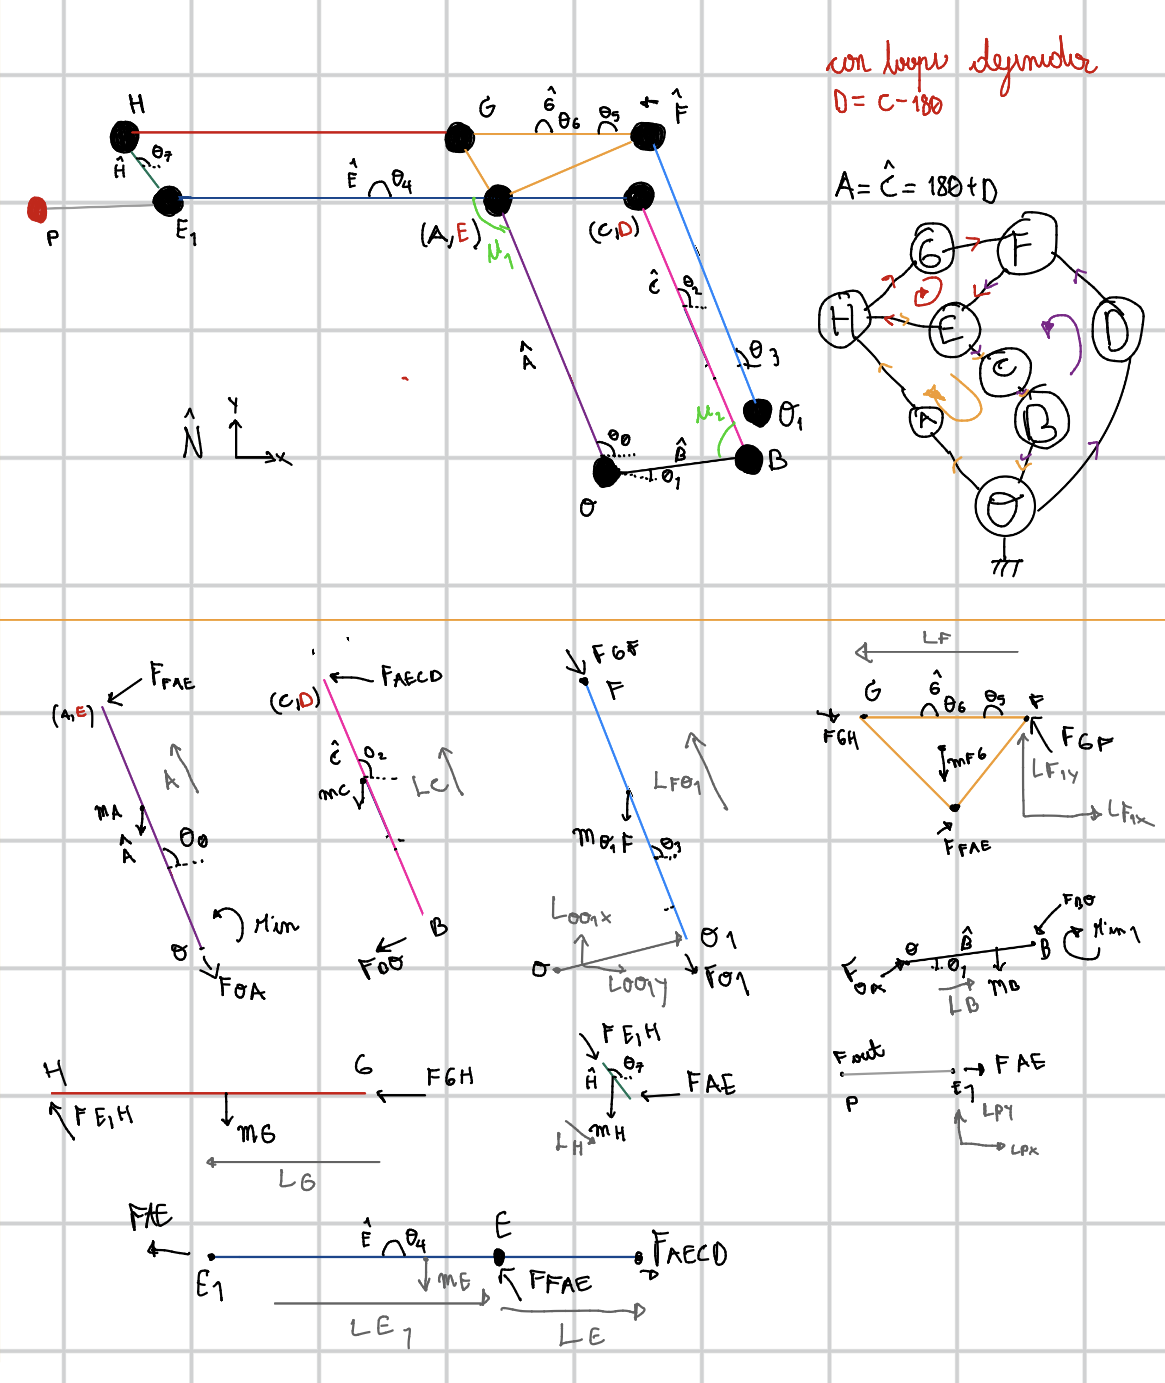



# 2. Cinemática directa: Implemente un código que genere la trayectoria de la punta del robot para un ciclo arbitrario de movimiento en ambos sevomotores que mueven el robot en el plano vertical. Demuestre su funcionamiento con un ejemplo.

In [1]:
#imports
import numpy as np
import sympy as sp
from sympy import symbols
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols
from scipy.optimize import least_squares, fsolve
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import pi
import ipywidgets as widgets
from ipywidgets import interactive_output
from IPython.display import display, clear_output

In [2]:
#aux functions
    # getComponents (dot en x,y,z)
def getComponents(v, frame):
    return [v.dot(frame.x), v.dot(frame.y), v.dot(frame.z)]
    #momentum about z
def Mz_about_cm(r_app, r_cm, F):
    return (r_app - r_cm).cross(F).dot(N.z)


In [3]:
#Frames
N = ReferenceFrame('N') #global
bodies = ['A','B','C','D','E','F','G','H'] #body names
theta = dynamicsymbols('theta0:'+str(len(bodies)))  # theta0..theta7
frames = {body: N.orientnew(body, 'Axis', [theta[i], N.z]) for i, body in enumerate(bodies)} #create frames on dictioary with body names as keys and oriented

#frames to body angle
[print(i)for i in zip(frames.keys(),theta)]


('A', theta0(t))
('B', theta1(t))
('C', theta2(t))
('D', theta3(t))
('E', theta4(t))
('F', theta5(t))
('G', theta6(t))
('H', theta7(t))


[None, None, None, None, None, None, None, None]

In [4]:
#Definitions
LA, LB, LC, LD, LG, LH, LE, LE1, LF, LF1x, LF1y, L001x, L001y, LPx, LPy = sp.symbols('LA, LB, LC, LD, LG, LH, LE, LE1, LF, LF1x, LF1y,L001x, L001y, LPx, LPy')
t = dynamicsymbols._t
#Params
    #lenght in meters
params = {
    LA:80e-3, LB:35e-3, LC:80e-3, LD:80e-3, LG:80e-3, LH:20e-3,
    LE:35e-3, LE1:80e-3, LF:46e-3, LF1x:36e-3, LF1y:17e-3,
    L001x:36e-3, L001y:17e-3, LPx:17e-3, LPy:38e-3
}


    #mass on kg, from inventor
params['mA'] = 13.847e-3
params['mC'] = 2.99e-3
params['mO1F'] = 2.99e-3
params['mFG'] = 4.57e-3
params['mB'] = 3.3e-3
params['mH'] = 7.07e-3
params['mE'] = 9.282e-3
params['mG'] = 2.99e-3

    #Inertia in kg*m^2 from inventor
params['IA'] = 9.95e-2
params['IC'] = 2.609e-2
params['IO1F'] = 2.609e-2
params['IFG'] = 1.10e-2
params['IB'] = 5.156e-3
params['IH'] = 1.854e-2 #total inertia on H an P member
params['IE'] = 1.260e-1
params['IG'] = 2.609e-2  

    #Distance to mass center from inventor
params['LAcm'] = 40e-3      
params['LBcm'] = 17.5e-3   
params['LCcm'] = 40e-3     
params['LEcm'] = 17e-3     
params['LGcm'] = 40e-3     
params['LHcm'] = 25e-3      
params['L01Fcmx'] = 17e-3
params['L01Fcmy'] = 17e-3   
params['LPcm'] = 26e-3
params['LFG'] = 2.12e-3



In [5]:
#points dct 
points = {}
points['O'] = 0*N.x
points['O1'] = points['O'] + L001x*N.x + L001y*N.y
points['A']  = LA*frames['A'].x
points['B']  = LB*frames['B'].x
points['C']  = points['B'] + LC*frames['C'].x
points['D']  = points['B'] - LD*frames['D'].x
points['E']  = points['C'] - LE*frames['E'].x
points['E1']  = points['C'] - (LE+LE1)*frames['E'].x
points['H']  = points['E1'] + LH*frames['H'].x
points['G']  = points['H'] + LG*frames['G'].x
points['F']  = points['G'] + LF*frames['F'].x
points['P'] = points['E1'] + LPx*frames['H'].x + LPy*frames['H'].y #end-effector

In [6]:
# Loop equations 
eq1 = points['E'] + LF1x*frames['F'].x + LF1y*frames['F'].y + LD*frames['D'].x - points['O1']
eq2 = points['E'] - points['A']
eq3 = LH*frames['H'].x + LG*frames['G'].x + (LF-LF1x)*frames['F'].x - LF1y*frames['F'].y - LE1*frames['E'].x

eq = getComponents(eq1, N)[0:2] + getComponents(eq2, N)[0:2] + getComponents(eq3, N)[0:2]
eq = [e.subs(params) for e in eq]
eq_fun = sp.lambdify(theta, eq, 'numpy')

# points_fun (x,y)
points_fun = { k: sp.lambdify(theta, [v.dot(N.x).subs(params), v.dot(N.y).subs(params)])for k, v in points.items()}
z0 = np.deg2rad([90, -90, 0, 0, 0, 100])

# FK
def FK(thetaA, thetaB):
    sln = fsolve(lambda z: eq_fun(thetaA, thetaB, *z), z0)
    return sln


In [7]:
# Plot of Mechanism 
def plotMechanism(thetas, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    #points position
    O = points_fun['O'](*thetas)
    O1 = points_fun['O1'](*thetas)
    A = points_fun['A'](*thetas)
    B = points_fun['B'](*thetas)
    C = points_fun['C'](*thetas)
    D = points_fun['D'](*thetas)
    E = points_fun['E'](*thetas)
    E1 = points_fun['E1'](*thetas)
    H = points_fun['H'](*thetas)
    G = points_fun['G'](*thetas)
    F = points_fun['F'](*thetas)
    P = points_fun['P'](*thetas)

    # members plot
    ax.plot([O[0], A[0]], [O[1], A[1]], color='purple')      # A
    ax.plot([O[0], B[0]], [O[1], B[1]], color='black')       # B
    ax.plot([B[0], D[0]], [B[1], D[1]], color='pink')     # D
    ax.plot([C[0], E1[0]], [C[1], E1[1]], color='darkblue')      # E 
    ax.plot([E1[0], H[0]], [E1[1], H[1]], color='green')   # H
    ax.plot([H[0], G[0]], [H[1], G[1]], color='red')      # G
    ax.plot([G[0], F[0]], [G[1], F[1]], color='orange')      # F
    ax.plot([A[0], F[0]], [A[1], F[1]], color='orange')      # F
    ax.plot([O1[0], F[0]], [O1[1], F[1]], color='blue')     # F
    ax.plot([G[0], E[0]], [G[1], E[1]], color='orange')      # F
    ax.plot([E1[0], P[0]], [E1[1], P[1]], color='gray')     # p

    #joints plot
    ax.plot(O[0], O[1], 'ko')
    ax.plot(O1[0], O1[1], 'ko')
    ax.plot(A[0], A[1], 'ko')
    ax.plot(B[0], B[1], 'ko')
    ax.plot(C[0], C[1], 'ko')
    ax.plot(D[0], D[1], 'ko')
    ax.plot(E[0], E[1], 'ko')
    ax.plot(E1[0], E1[1], 'ko')
    ax.plot(H[0], H[1], 'ko')
    ax.plot(G[0], G[1], 'ko')
    ax.plot(F[0], F[1], 'ko')
    ax.plot(P[0], P[1], 'ko', color='r')

    #globals params
    ax.set_aspect('equal')
    ax.grid()
  
    return ax


# Ejemplo

In [8]:
# Example of use 
x = np.deg2rad(110), np.deg2rad(30)

z = FK(*x)

fig, ax1 = plt.subplots(figsize=(12,7), dpi=1000)
plotMechanism([*x, *z], ax=ax1)
ax1.set_title(f'Robot Mechanism sample Configuration with input angles θ0={np.rad2deg(x[0]):.2f}° and θ1={np.rad2deg(x[1]):.2f}°')
ax1.set_xlabel('X position [m]')
ax1.set_ylabel('Y position [m]')
plt.show()

print('Joint angles (degrees):')
print(' θ0 & θ1 are the input angles, servo')
for i, val in enumerate([*x, *z]):
    print(f'θ{i} = {np.rad2deg(val):.2f}°')


/var/folders/zl/hrt8lnh14rs7lmm5_d_43zvw0000gn/T/ipykernel_51043/2350459395.py:44: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  ax.plot(P[0], P[1], 'ko', color='r')


Joint angles (degrees):
 θ0 & θ1 are the input angles, servo
θ0 = 110.00°
θ1 = 30.00°
θ2 = 110.00°
θ3 = -70.00°
θ4 = 30.00°
θ5 = -0.00°
θ6 = 29.80°
θ7 = 120.46°


# 3. En el código del puno 2 incluya una gráfica animada que muestre el movimiento de todos los segmentos en los mecanismos del robot y visualice el ángulo de transmisión sobre la unión de la salida de cada servomotor y su valor en grados.
    Se presentan dos ejemplos, uno ilusrativo y otro que se utilizara para desarrollar el iteral 4. El primeo ilustra para cada posición  la configuración completa del robot y se graficaron todos los eslabones, apartir de los angulos de entrada vistos como sliders  e IK . Para el análisis dinámico, segundo ejemplo, los ángulos de entrada se modelaron como funciones senoidales del tiempo, lo que permite obtener velocidades y aceleraciones mediante derivación numérica.
    Se muestran los ángulos de transmisión en cada servo, que indican qué tan bien se transmite el movimiento en esa posición.
    

# Ejemplo Basico, con angulos constantes sin entrada especifica

In [16]:
# transmission angles
def angle_between(u, v): 
    u = np.array(u, dtype=float)
    v = np.array(v, dtype=float)
    nu = np.linalg.norm(u); nv = np.linalg.norm(v)
    if nu == 0 or nv == 0: #sanity check
        return np.nan
    c = np.clip(np.dot(u, v)/(nu*nv), -1.0, 1.0)
    return np.arccos(c)  # rad

def transmission_angles_mu1_mu2(thetas):
    O  = np.array(points_fun['O'](*thetas), float)
    A  = np.array(points_fun['A'](*thetas), float)
    B  = np.array(points_fun['B'](*thetas), float)
    C  = np.array(points_fun['C'](*thetas), float)
    E1 = np.array(points_fun['E1'](*thetas), float)
    # μ1 en A: AO (servo) vs AE1 joint member (acoplado)
    u1 = O  - A
    v1 = E1 - A
    mu1 = angle_between(u1, v1)
    # μ2 en B: BO (servo) vs BC joint member (acomplado)
    u2 = O - B
    v2 = C - B
    mu2 = angle_between(u2, v2)
    return mu1, mu2
# slider widgets from https://stackoverflow.com/questions/72267070/using-dynamic-number-of-sliders-with-ipywidgets
s0 = widgets.FloatSlider(value=120, min=90, max=180, step=1,description=r'θ0 (deg)', continuous_update=False)
s1 = widgets.FloatSlider(value=0, min=0, max=90, step=1,description=r'θ1 (deg)', continuous_update=False)
out = widgets.Output()
def draw(theta0_deg, theta1_deg):
    with out:
        clear_output(wait=True)
        x = np.deg2rad(theta0_deg), np.deg2rad(theta1_deg)
        # Forward kinematics
        z = FK(*x)
        thetas = [*x, *z]
        # transmission angles
        mu1, mu2 = transmission_angles_mu1_mu2(thetas)
        # plot
        fig, ax = plt.subplots(figsize=(7, 6), dpi=130)
        plotMechanism(thetas, ax=ax)
        ax.set_title(rf'Robot mechanism | $\theta_0$={theta0_deg:.0f}°  $\theta_1$={theta1_deg:.0f}°')
        ax.set_xlabel('X position [m]')
        ax.set_ylabel('Y position [m]')
        ax.text(
            0.02, 0.02,
            rf'$\mu_1$ (OA vs AE1) = {np.rad2deg(mu1):.1f}°' '\n'
            rf'$\mu_2$ (OB vs BC)  = {np.rad2deg(mu2):.1f}°',
            transform=ax.transAxes,
            va="bottom"
        )
        plt.show()

# display ipwidgets library
ui = widgets.VBox([s0, s1])
out_ui = interactive_output(draw, {'theta0_deg': s0, 'theta1_deg': s1})
display(ui, out_ui, out)
draw(s0.value, s1.value)


Output()

Output()

# Ejemplo 2, animacion ustilizando parametrizacion seno para los servomotores, si se quiere correr el slider anterior toca volver a ejecutar la celda (ejemplo 1), por errores de compatibilidad de la libreria
    Movimiento  de los servomotores se define mediante funciones senoidales para garantizar suavidad en velocidad y aceleración, esta parametrizado por las siguientes expresiones:

$$
\theta_0(t) = \frac{\theta_{0,\min} + \theta_{0,\max}}{2}
+ \frac{\theta_{0,\max} - \theta_{0,\min}}{2}\,\sin(t)
$$

$$
\theta_1(t) = \frac{\theta_{1,\min} + \theta_{1,\max}}{2}
+ \frac{\theta_{1,\max} - \theta_{1,\min}}{2}\,\sin(t)
$$

In [10]:
n = 120
tt = np.linspace(0, 2*np.pi, n)
#Range
theta0_min, theta0_max = 90, 120
theta1_min, theta1_max = 0, 90
# sin trayectories
theta0_traj = np.deg2rad((theta0_min+theta0_max)/2) + \
              np.deg2rad((theta0_max-theta0_min)/2)*np.sin(tt)

theta1_traj = np.deg2rad((theta1_min+theta1_max)/2) + \
              np.deg2rad((theta1_max-theta1_min)/2)*np.sin(tt)
play = widgets.Play(interval=50, value=0, min=0, max=n-1, step=1)
slider = widgets.IntSlider(min=0, max=n-1, step=1)
widgets.jslink((play, 'value'), (slider, 'value'))
out = widgets.Output()

def update(i):
    with out:
        clear_output(wait= False)
        x0 = theta0_traj[i]
        x1 = theta1_traj[i]
        z = FK(x0, x1)
        thetas = [x0, x1, *z]
        mu1, mu2 = transmission_angles_mu1_mu2(thetas)
        fig, ax = plt.subplots(figsize=(12,7), dpi=500)
        plotMechanism(thetas, ax=ax)
        ax.set_title(
            rf'$\theta_0$={np.rad2deg(x0):.1f}°   $\theta_1$={np.rad2deg(x1):.1f}°'
        )
        ax.set_xlabel('X position [m]')
        ax.set_ylabel('Y position [m]')
        ax.text(
            0.02, 0.02,
            rf'$\mu_1$ = {np.rad2deg(mu1):.1f}°' '\n'
            rf'$\mu_2$ = {np.rad2deg(mu2):.1f}°',
            transform=ax.transAxes
        )

ui = widgets.VBox([
    widgets.HBox([play, slider])])
out_ui = widgets.interactive_output(update, {'i': slider})
display(ui, out_ui, out)


Output()

Output()

# 4. Dinámica Inversa: Implemente un código que calcule el torque de entrada requerido para mover el mecanismo en el ciclo de movimiento planteado en el item 2. Puede despreciar fuentes de fricción.

In [11]:
#Params
FOAx, FOAy = dynamicsymbols('FOAx FOAy')
FAEx, FAEy = dynamicsymbols('FAEx FAEy')
FBOx, FBOy = dynamicsymbols('FBOx FBOy')
FBCx, FBCy = dynamicsymbols('FBCx FBCy')     
FO1Fx, FO1Fy = dynamicsymbols('FO1Fx FO1Fy')
FGFx, FGFy = dynamicsymbols('FGFx FGFy')
FGHx, FGHy = dynamicsymbols('FGHx FGHy')
FEHx, FEHy = dynamicsymbols('FEHx FEHy')
FAECDx, FAECDy = dynamicsymbols('FAECDx FAECDy')
Min, MB = dynamicsymbols('Min MB')  
g = sp.Symbol('g', real=True)

mass_center = {
       'A': points['O'] + params['LAcm']*frames['A'].x,
       'B': points['O'] + params['LBcm']*frames['B'].x,
       'C': points['B'] + params['LCcm']*frames['C'].x,
       'D': points['B'] + params['LCcm']*frames['D'].x,

       'E': points['D'] + params['LEcm']*frames['E'].x,
       'H': points['E1'] - params['LHcm']*frames['H'].x,
       'G': points['H'] + params['LGcm']*frames['G'].x,
       'FG': points['F'] - params['LFG']*frames['F'].x,
       'O1F': points['O1'] - params['L01Fcmx']*N.x - params['L01Fcmy']*N.y,
}

#3#forces Definiitions
FOAx, FOAy = dynamicsymbols('FOAx FOAy')
FAEx, FAEy = dynamicsymbols('FAEx FAEy')
FBOx, FBOy = dynamicsymbols('FBOx FBOy')
FBCx, FBCy = dynamicsymbols('FBCx FBCy')
FO1Fx, FO1Fy = dynamicsymbols('FO1Fx FO1Fy')
FGFx, FGFy = dynamicsymbols('FGFx FGFy')
FGHx, FGHy = dynamicsymbols('FGHx FGHy')
FEHx, FEHy = dynamicsymbols('FEHx FEHy')
FAECDx, FAECDy = dynamicsymbols('FAECDx FAECDy')

#forces as vectors
FOA   = FOAx*frames['A'].x + FOAy*frames['A'].y
FAE   = FAEx*frames['E'].x + FAEy*frames['E'].y
FBO   = FBOx*frames['B'].x + FBOy*frames['B'].y
FO1F  = FO1Fx*N.x + FO1Fy*N.y
FGF   = FGFx*frames['F'].x + FGFy*frames['F'].y
FGH   = FGHx*frames['H'].x + FGHy*frames['H'].y
FEH   = FEHx*frames['H'].x + FEHy*frames['H'].y
FAECD = FAECDx*frames['E'].x + FAECDy*frames['E'].y
g_vec = g*N.y

# center of mass acceleration
aA = mass_center['A'].dt(N).dt(N)
aB = mass_center['B'].dt(N).dt(N)
aC = mass_center['C'].dt(N).dt(N)
aE = mass_center['E'].dt(N).dt(N)
aG = mass_center['G'].dt(N).dt(N)
aH = mass_center['H'].dt(N).dt(N)
aO1F = mass_center['O1F'].dt(N).dt(N)
aFG = mass_center['FG'].dt(N).dt(N) 

#forces eq on each body
eqFA = FOA - FAE - params['mA']*g_vec - params['mA']*aA
eqFB = FOA - FBO - params['mB']*g_vec - params['mB']*aB
eqFC = FBO- FAECD - params['mC']*g_vec - params['mC']*aC
eqFE = FAE - FAECD - params['mE']*g_vec - params['mE']*aE
eqFO1F = FO1F - FGF - params['mO1F']*g_vec - params['mO1F']*aO1F
eqFFG = -FGH - FGF + FAE- params['mFG']*g_vec - params['mFG']*aFG
eqFH = FEH - FAE - params['mH']*g_vec - params['mH']*aH
eqFG = -FGH - FEH - params['mG']*g_vec - params['mG']*aG

In [12]:
#forces eq on each body
eqFA   = FOA - FAE   - params['mA']*g_vec   - params['mA']*aA
eqFB   = FOA - FBO   - params['mB']*g_vec   - params['mB']*aB
eqFC   = FBO - FAECD - params['mC']*g_vec   - params['mC']*aC
eqFE   = FAE - FAECD - params['mE']*g_vec   - params['mE']*aE
eqFO1F = FO1F - FGF  - params['mO1F']*g_vec - params['mO1F']*aO1F
eqFFG  = -FGH - FGF + FAE - params['mFG']*g_vec - params['mFG']*aFG
eqFH   = FEH - FAE   - params['mH']*g_vec   - params['mH']*aH
eqFG   = -FGH - FEH  - params['mG']*g_vec   - params['mG']*aG

#IA on params
IA  = float(params['IA'])
IB  = float(params['IB'])
IC  = float(params['IC'])
IE  = float(params['IE'])
IO1F= float(params['IO1F'])
IFG = float(params['IFG'])
IG  = float(params['IG'])
IH  = float(params['IH'])


In [13]:
g_vec = g*N.y


#angular acceleration (z)
alphaA = frames['A'].ang_acc_in(N).dot(N.z) #frame A angular acceleration in N, projected olong z
alphaB = frames['B'].ang_acc_in(N).dot(N.z)
alphaC = frames['C'].ang_acc_in(N).dot(N.z)
alphaE = frames['E'].ang_acc_in(N).dot(N.z)
alphaF = frames['F'].ang_acc_in(N).dot(N.z)
alphaG = frames['G'].ang_acc_in(N).dot(N.z)
alphaH = frames['H'].ang_acc_in(N).dot(N.z)

#momentum eq on each body
eqMA = (
    Min
    + Mz_about_cm(points['O'], mass_center['A'], FOA)
    + Mz_about_cm(points['A'], mass_center['A'], -FAE)
    - IA*alphaA
)

eqMB = (
    MB
    + Mz_about_cm(points['O'], mass_center['B'], FOA)
    + Mz_about_cm(points['B'], mass_center['B'], -FBO)
    - IB*alphaB
)

eqMC = (
    Mz_about_cm(points['B'], mass_center['C'], FBO)
    + Mz_about_cm(points['D'], mass_center['C'], -FAECD)
    - IC*alphaC
)

eqME = (
    Mz_about_cm(points['A'], mass_center['E'], FAE)
    + Mz_about_cm(points['D'], mass_center['E'], -FAECD)
    - IE*alphaE
)

eqMO1F = (
    Mz_about_cm(points['O1'], mass_center['O1F'], FO1F)
    + Mz_about_cm(points['F'],  mass_center['O1F'], -FGF)
    - IO1F*alphaF
)

eqMFG = (
    Mz_about_cm(points['F'],  mass_center['FG'], -FGF)
    + Mz_about_cm(points['G'], mass_center['FG'], -FGH)
    + Mz_about_cm(points['A'], mass_center['FG'],  FAE)
    - IFG*alphaF
)

eqMH = (
    Mz_about_cm(points['E1'], mass_center['H'], FEH)
    + Mz_about_cm(points['A'],  mass_center['H'], -FAE)
    - IH*alphaH
)

eqMG = (
    Mz_about_cm(points['G'], mass_center['G'], -FGH)
    + Mz_about_cm(points['H'], mass_center['G'], -FEH)
    - IG*alphaG
)


Promedio Min (A) = 0.0003 N·m
Promedio MB  (B) = -0.0001 N·m


/Users/sergioe.ropero/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/sergioe.ropero/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/sergioe.ropero/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


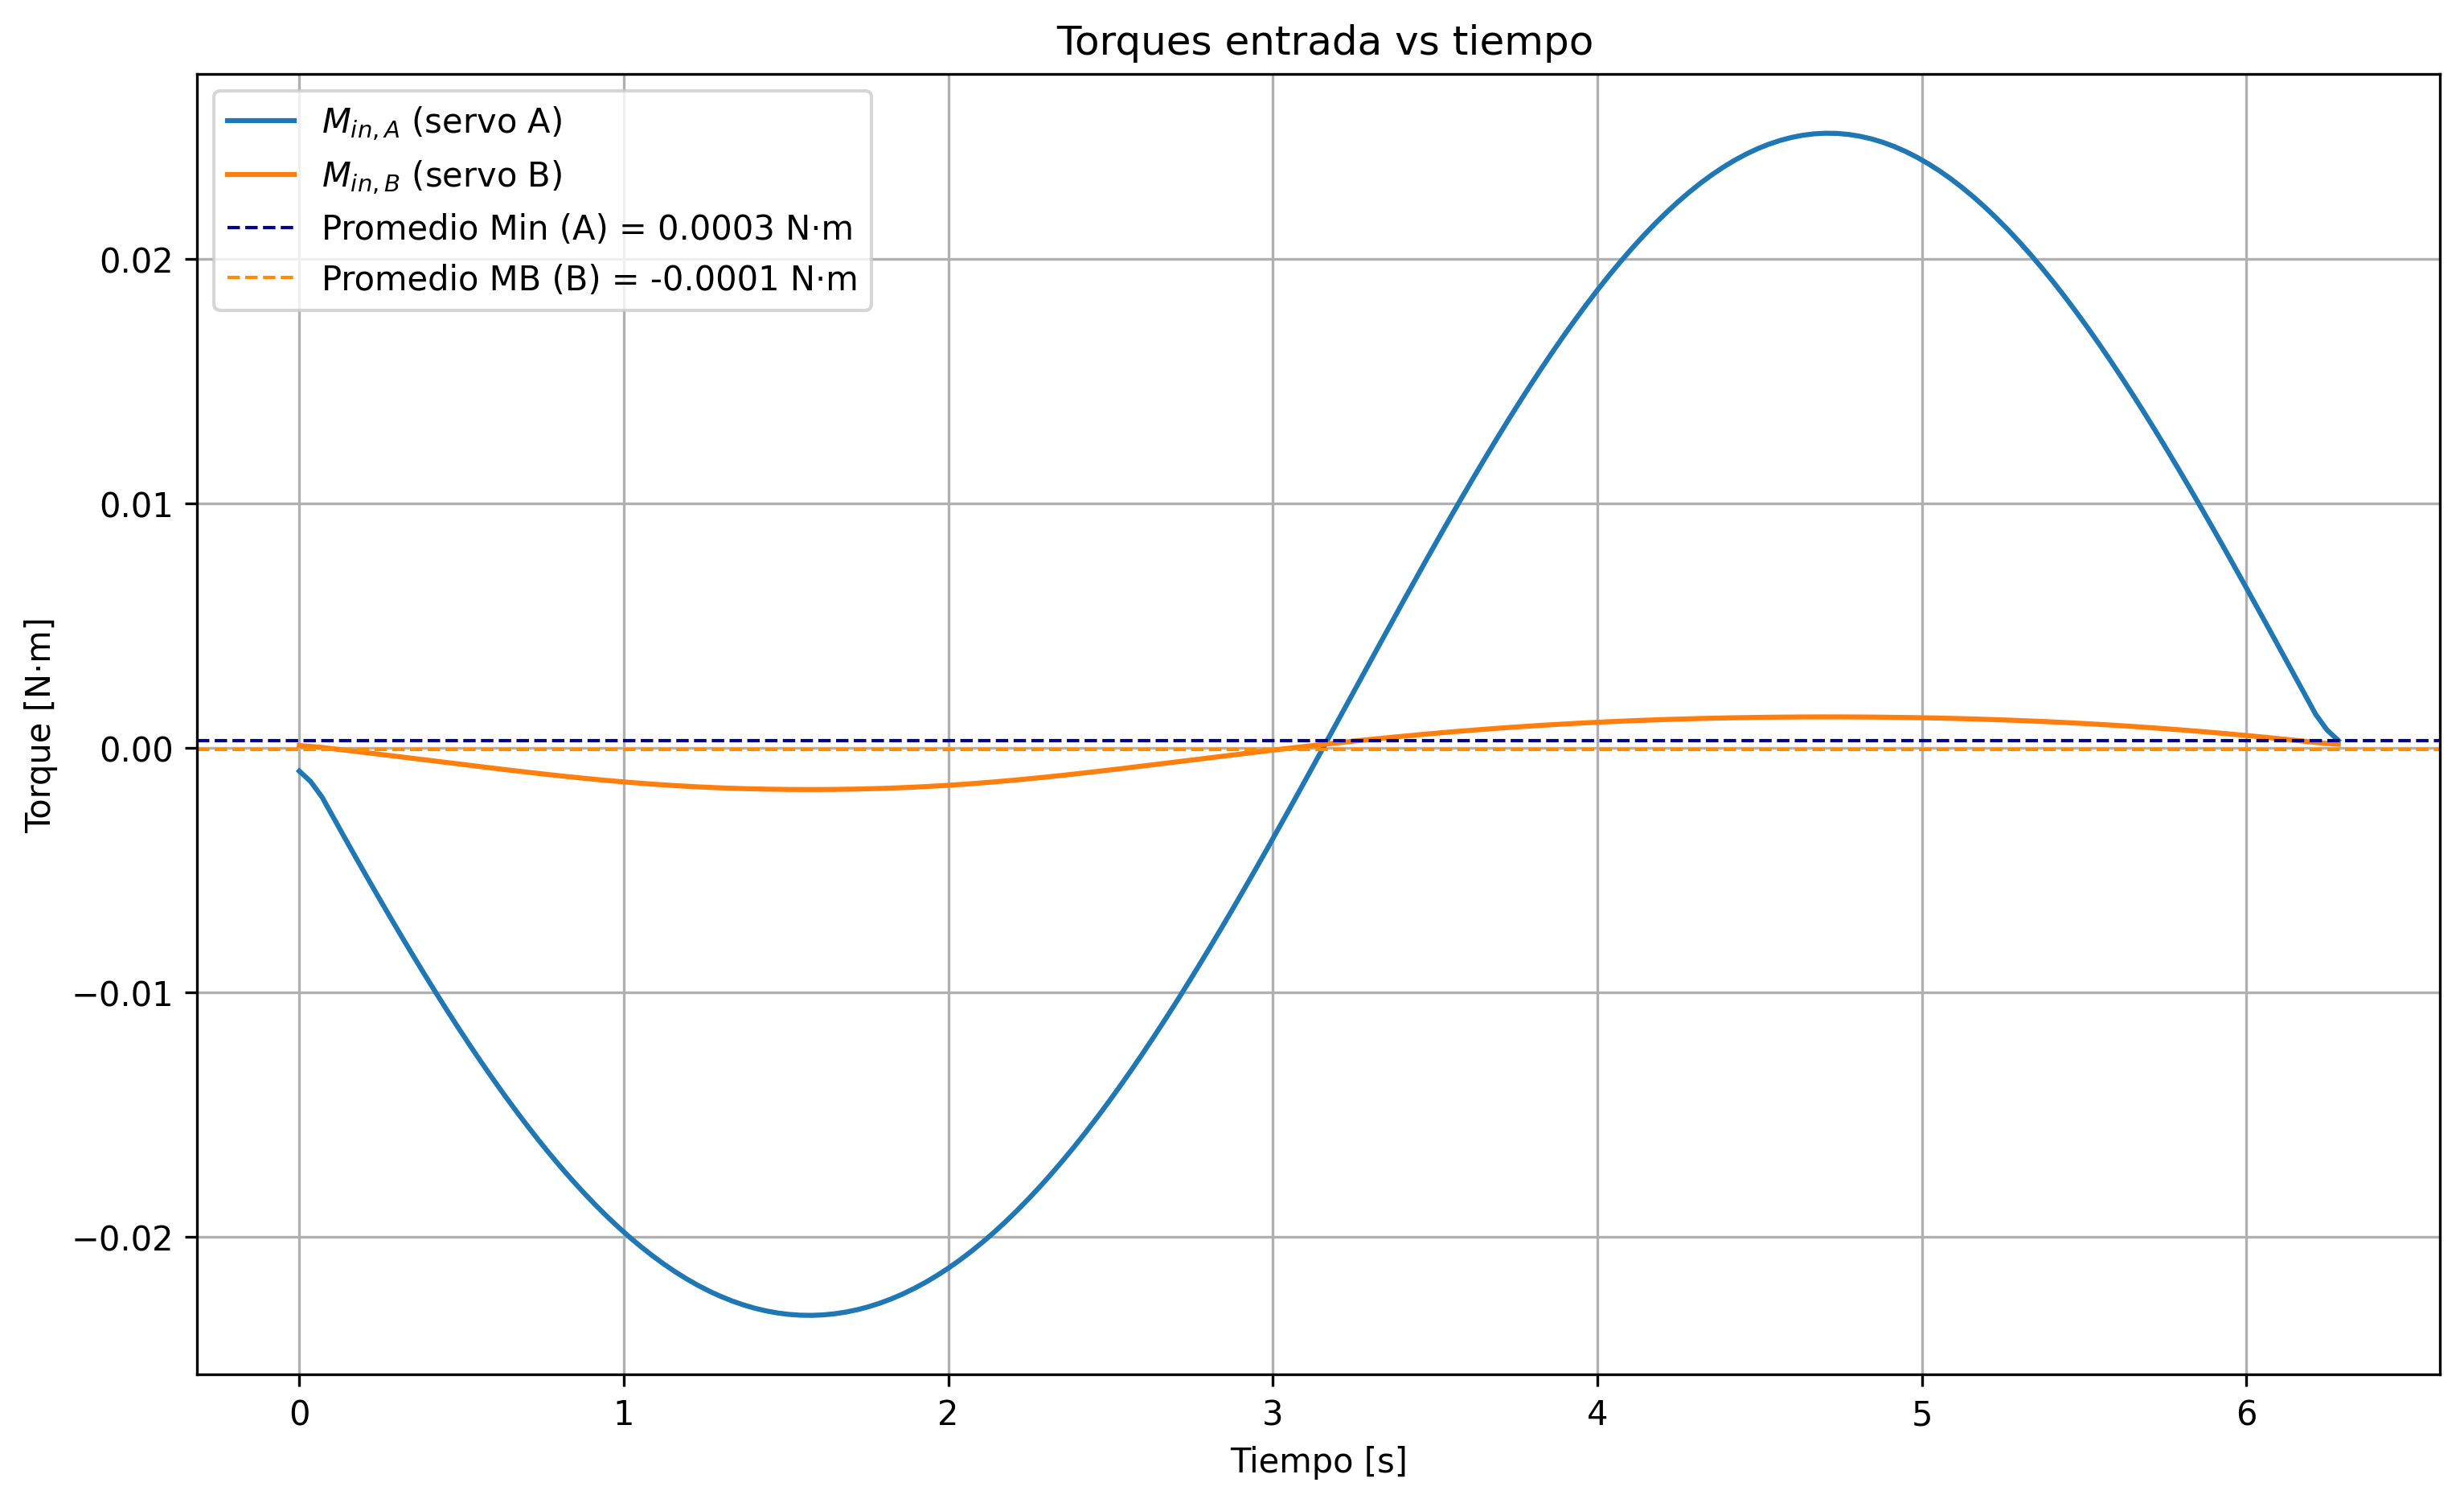

In [14]:
eqs = [] #eq matrix for forces and moments
# Forces (x,y)
for eq in [eqFA, eqFB, eqFC, eqFE, eqFO1F, eqFFG, eqFH, eqFG]:
    eqs += [sp.simplify(eq.dot(N.x)), sp.simplify(eq.dot(N.y))]

# Momentum (z)
for eq in [eqMA, eqMB, eqMC, eqME, eqMO1F, eqMFG, eqMH, eqMG]:
    eqs += [sp.simplify(eq)]
eqs = [e for e in eqs if e != 0] #delete zero eqs (if any)
unknowns = [
    FOAx, FOAy,
    FAEx, FAEy,
    FBOx, FBOy,
    FO1Fx, FO1Fy,
    FGFx, FGFy,
    FGHx, FGHy,
    FEHx, FEHy,
    FAECDx, FAECDy,
    Min, MB
]
FF, bf = sp.linear_eq_to_matrix(eqs, unknowns) 


FF_sub = FF.subs(params).subs({g: 9.81})
bf_sub = bf.subs(params).subs({g: 9.81})


theta_syms = theta  

dot_theta_syms  = [th.diff(t) for th in theta_syms]
ddot_theta_syms = [th.diff(t, 2) for th in theta_syms]
FF_fun = sp.lambdify(dot_theta_syms + theta_syms, FF_sub, 'numpy')
bf_fun = sp.lambdify(ddot_theta_syms + dot_theta_syms + theta_syms, bf_sub, 'numpy')

Npts = 180
tau = np.linspace(0, 2*np.pi, Npts)     # Parameter for trajectory (not time, yet)
tList = tau                     # time [s]


#thea range
thetaA_min, thetaA_max = 90, 120
thetaB_min, thetaB_max = 0, 90

thetaA_traj = np.deg2rad((thetaA_min+thetaA_max)/2) + np.deg2rad((thetaA_max-thetaA_min)/2)*np.sin(tau)
thetaB_traj = np.deg2rad((thetaB_min+thetaB_max)/2) + np.deg2rad((thetaB_max-thetaB_min)/2)*np.sin(tau)



theta_mat = np.zeros((Npts, len(theta_syms)), dtype=float)
for i in range(Npts):
    thA = float(thetaA_traj[i])
    thB = float(thetaB_traj[i])
    z = FK(thA, thB)              # sol
    theta_mat[i, :] = np.array([thA, thB, *z], dtype=float)

# numerical differentiation
theta_dot  = np.gradient(theta_mat, tList, axis=0, edge_order=2)
theta_ddot = np.gradient(theta_dot, tList, axis=0, edge_order=2)

#mask for moments
Min_list = np.zeros(Npts, dtype=float)
MB_list  = np.zeros(Npts, dtype=float)

idx_Min = unknowns.index(Min)
idx_MB  = unknowns.index(MB)

for i in range(Npts):
    th   = theta_mat[i, :].tolist()
    thd  = theta_dot[i, :].tolist()
    thdd = theta_ddot[i, :].tolist()

    FF_num = np.array(FF_fun(*([*thd, *th])), dtype=float)
    bf_num = np.array(bf_fun(*([*thdd, *thd, *th])), dtype=float).reshape(-1)

    sol = np.linalg.pinv(FF_num) @ bf_num #solve for forces and moments

    Min_list[i] = float(sol[idx_Min])
    MB_list[i]  = float(sol[idx_MB])


#plots
fig, ax = plt.subplots(figsize=(12,7), dpi=300)
ax.plot(tList, Min_list, label=r'$M_{in,A}$ (servo A)')
ax.plot(tList, MB_list,  label=r'$M_{in,B}$ (servo B)')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Torque [N·m]')
ax.set_title(' Torques entrada vs tiempo')
ax.grid(True)
ax.legend()
# Mean
ax.axhline(Min_list.mean(), linestyle='--', linewidth=1, label=f"Promedio Min (A) = {Min_list.mean():.4f} N·m", color='darkblue')
ax.axhline(MB_list.mean(),  linestyle='--', linewidth=1, label=f"Promedio MB (B) = {MB_list.mean():.4f} N·m", color='darkorange')
print(f"Promedio Min (A) = {Min_list.mean():.4f} N·m")
print(f"Promedio MB  (B) = {MB_list.mean():.4f} N·m")
ax.legend()
plt.show()